In [1]:
import torch
import torchxrayvision as xrv

print("PyTorch Version :", torch.__version__)
print("TorchXRayVision Installed Successfully!")

PyTorch Version : 2.13.0+cpu
TorchXRayVision Installed Successfully!


C:\Users\Gobika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torchxrayvision as xrv

print("TorchXRayVision Version:", xrv.__version__)
print("\nAvailable modules:")
print(dir(xrv))

TorchXRayVision Version: 1.5.2

Available modules:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'autoencoders', 'baseline_models', 'datasets', 'models', 'utils']


In [3]:
import torchxrayvision as xrv

print("Available Models:\n")

for item in dir(xrv.models):
    if not item.startswith("_"):
        print(item)

Available Models:

DenseNet
F
List
Model
OrderedDict
ResNet
datasets
get_densenet_params
get_model
get_weights
model_urls
nn
np
op_norm
os
pathlib
requests
sys
torch
torchvision
utils
warnings


In [4]:
print("Available Utils:\n")

for item in dir(xrv.utils):
    if not item.startswith("_"):
        print(item)

Available Utils:

PathLike
download
fix_resolution
get_cache_dir
in_notebook
infer
load_image
ndarray
normalize
np
os
read_xray_dcm
requests
skimage
sys
torch
tqdm
warn_normalization
warning_log
warnings


In [5]:
import torchxrayvision as xrv

print(dir(xrv.baseline_models))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'chestx_det', 'chexpert', 'emory_hiti', 'jfhealthcare', 'mira', 'riken', 'xinario']


In [6]:
print(dir(xrv.baseline_models.chestx_det))

['List', 'OrderedDict', 'PSPNet', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_convert_state_dict', 'nn', 'os', 'pathlib', 'pspnet', 'ptsemseg', 'torch', 'torchvision', 'utils', 'xrv']


In [7]:
import inspect
import torchxrayvision as xrv

print(inspect.signature(xrv.baseline_models.chestx_det.PSPNet))

(cache_dir: str = None)


In [8]:
help(xrv.baseline_models.chestx_det.PSPNet)

Help on class PSPNet in module torchxrayvision.baseline_models.chestx_det:

class PSPNet(torch.nn.modules.module.Module)
 |  PSPNet(cache_dir: str = None)
 |
 |  ChestX-Det anatomical segmentation model (PSPNet)
 |
 |  A PSPNet model pre-trained for pixel-level segmentation of 14 anatomical
 |  structures in chest X-rays. Output shape is ``[batch, 14, 512, 512]``.
 |
 |  **Targets (14):** Left Clavicle, Right Clavicle, Left Scapula, Right
 |  Scapula, Left Lung, Right Lung, Left Hilus Pulmonis, Right Hilus
 |  Pulmonis, Heart, Aorta, Facies Diaphragmatica, Mediastinum, Weasand,
 |  Spine.
 |
 |  `Demo notebook <https://github.com/mlmed/torchxrayvision/blob/main/scripts/segmentation.ipynb>`_
 |
 |  .. code-block:: python
 |
 |      seg_model = xrv.baseline_models.chestx_det.PSPNet()
 |      output = seg_model(image)
 |      output.shape  # [1, 14, 512, 512]
 |
 |  .. image:: _static/segmentation-pspnet.png
 |
 |  :param cache_dir: Directory used to store downloaded weights
 |      (defa

In [9]:
# ==========================================================
# STEP 1 : Import Required Libraries
# Project : Multimodal Tuberculosis Detection
# Purpose : Load all libraries required for lung segmentation
# ==========================================================

# PyTorch (Deep Learning Framework)
import torch

# TorchXRayVision (Chest X-ray Research Library)
import torchxrayvision as xrv

# OpenCV (Image Processing)
import cv2

# NumPy (Numerical Operations)
import numpy as np

# Matplotlib (Image Visualization)
import matplotlib.pyplot as plt

# Operating System Library
import os

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [10]:
# ==========================================================
# STEP 2 : Load Pre-trained PSPNet Segmentation Model
# Purpose :
#   - Download (only first time)
#   - Load the anatomical segmentation model
#   - Switch model to evaluation mode
# ==========================================================

# Load the pre-trained PSPNet model
segmentation_model = xrv.baseline_models.chestx_det.PSPNet()

# Set the model to evaluation mode
# (No training, only prediction)
segmentation_model.eval()

print("Pre-trained PSPNet Model Loaded Successfully!")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/pspnet_chestxray_best_model_4.pth -O C:\Users\Gobika\.torchxrayvision\models_data/pspnet_chestxray_best_model_4.pth`
[██████████████████████████████████████████████████]
Pre-trained PSPNet Model Loaded Successfully!


Image Loaded Successfully!
Image Shape : (224, 224)
Image Data Type : uint8


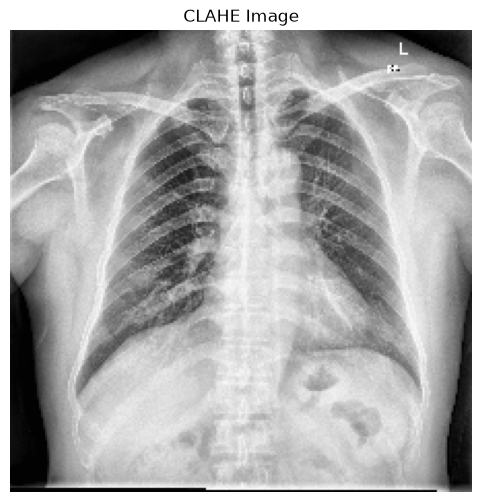

In [11]:
# ==========================================================
# STEP 3 : Read One CLAHE Image
# Purpose :
#   - Read one chest X-ray image
#   - Convert it to grayscale
#   - Display it
# ==========================================================

# Image path
image_path = "CLAHE_Images/CHNCXR_0001_0.png"

# Read image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check whether image is loaded
if image is None:
    print("Image Not Found!")
else:
    print("Image Loaded Successfully!")

# Display Image Information
print("Image Shape :", image.shape)
print("Image Data Type :", image.dtype)

# Display Image
plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title("CLAHE Image")
plt.axis("off")
plt.show()

In [12]:
# ==========================================================
# STEP 4 : Prepare Image for PSPNet
# Project : TB Detection using CoAtNet
# Purpose :
#   1. Read one CLAHE image
#   2. Normalize pixel values
#   3. Convert into PyTorch Tensor
#   4. Add Batch Dimension
# ==========================================================

import cv2
import torch
import numpy as np
import torchxrayvision as xrv

# ----------------------------------------------------------
# Read one CLAHE image
# ----------------------------------------------------------

image_path = "CLAHE_Images/CHNCXR_0001_0.png"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# ----------------------------------------------------------
# Convert uint8 image (0-255)
# to the range expected by TorchXRayVision
# ----------------------------------------------------------

image = xrv.utils.normalize(image, maxval=255, reshape=True)

# ----------------------------------------------------------
# Convert NumPy array into PyTorch Tensor
# ----------------------------------------------------------

image = torch.from_numpy(image).float()

# ----------------------------------------------------------
# Add Batch Dimension
#
# Before  : [1, H, W]
# After   : [1, 1, H, W]
# ----------------------------------------------------------

image = image.unsqueeze(0)

print("Image Tensor Shape :", image.shape)

Image Tensor Shape : torch.Size([1, 1, 224, 224])


In [1]:
import inspect

print(inspect.signature(xrv.utils.fix_resolution))

NameError: name 'xrv' is not defined

In [2]:
import inspect
import torch
import torchxrayvision as xrv

C:\Users\Gobika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(inspect.signature(xrv.utils.fix_resolution))

(x, resolution: int, model)


In [4]:
help(xrv.utils.fix_resolution)

Help on function fix_resolution in module torchxrayvision.utils:

fix_resolution(x, resolution: int, model)
    Check resolution of input and resize to match requested.



In [10]:
# Import Libraries

import torch
import torchxrayvision as xrv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [11]:
# Load PSPNet Model

segmentation_model = xrv.baseline_models.chestx_det.PSPNet()

segmentation_model.eval()

print("PSPNet Loaded Successfully!")

PSPNet Loaded Successfully!


In [12]:
# Read one CLAHE image

image_path = "CLAHE_Images/CHNCXR_0001_0.png"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(224, 224)


In [13]:
print(type(image))

<class 'numpy.ndarray'>


In [14]:
# ==========================================================
# STEP 4 : Normalize Image
# Purpose :
# Convert pixel values from 0-255 to the range expected
# by TorchXRayVision.
# ==========================================================

# Normalize image
image_normalized = xrv.utils.normalize(image, maxval=255)

print("Normalization Completed Successfully!")

print("Shape :", image_normalized.shape)
print("Minimum Value :", image_normalized.min())
print("Maximum Value :", image_normalized.max())
print("Data Type :", image_normalized.dtype)

Normalization Completed Successfully!
Shape : (224, 224)
Minimum Value : -1015.9686
Maximum Value : 1024.0
Data Type : float32


In [15]:
# ==========================================================
# STEP 5 : Convert NumPy Image to PyTorch Tensor
# ==========================================================

import torch

# Convert NumPy array into Tensor
image_tensor = torch.from_numpy(image_normalized)

# Add Channel Dimension
# (224,224) → (1,224,224)
image_tensor = image_tensor.unsqueeze(0)

# Add Batch Dimension
# (1,224,224) → (1,1,224,224)
image_tensor = image_tensor.unsqueeze(0)

print("Tensor Shape :", image_tensor.shape)
print("Tensor Type :", image_tensor.dtype)

Tensor Shape : torch.Size([1, 1, 224, 224])
Tensor Type : torch.float32


In [16]:
# ==========================================================
# STEP 6 : Resize Image to Model Resolution
# Purpose :
# Resize the input tensor to the resolution expected
# by the PSPNet segmentation model.
# ==========================================================

image_tensor = xrv.utils.fix_resolution(
    image_tensor,
    512,
    segmentation_model
)

print("Tensor Shape After Resize :", image_tensor.shape)

Tensor Shape After Resize : torch.Size([1, 1, 512, 512])


In [17]:
# ==========================================================
# STEP 7 : Run Anatomical Segmentation
# Purpose :
# Generate anatomical masks using the pre-trained PSPNet
# ==========================================================

with torch.no_grad():
    output = segmentation_model(image_tensor)

print("Output Shape :", output.shape)

Output Shape : torch.Size([1, 14, 512, 512])


In [18]:
# ==========================================================
# STEP 8 : Display Anatomical Structures
# ==========================================================

for i, organ in enumerate(segmentation_model.targets):
    print(f"{i} : {organ}")

0 : Left Clavicle
1 : Right Clavicle
2 : Left Scapula
3 : Right Scapula
4 : Left Lung
5 : Right Lung
6 : Left Hilus Pulmonis
7 : Right Hilus Pulmonis
8 : Heart
9 : Aorta
10 : Facies Diaphragmatica
11 : Mediastinum
12 : Weasand
13 : Spine


In [19]:
# ==========================================================
# STEP 9 : Extract Left and Right Lung Masks
# Project : TB Detection
# Purpose :
#    Extract only the lung masks from the
#    14 predicted anatomical structures.
# ==========================================================

# Left Lung Mask
left_lung = output[0, 4].cpu().numpy()

# Right Lung Mask
right_lung = output[0, 5].cpu().numpy()

print("Left Lung Shape :", left_lung.shape)
print("Right Lung Shape :", right_lung.shape)

Left Lung Shape : (512, 512)
Right Lung Shape : (512, 512)


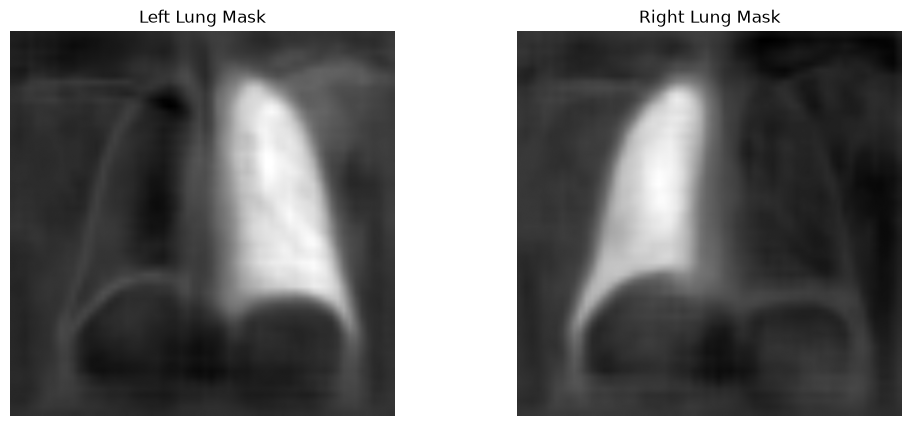

In [20]:
# ==========================================================
# STEP 10 : Display Predicted Lung Masks
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(left_lung, cmap='gray')
plt.title("Left Lung Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(right_lung, cmap='gray')
plt.title("Right Lung Mask")
plt.axis("off")

plt.show()

In [21]:
# ==========================================================
# STEP 11 : Combine Both Lung Masks
# ==========================================================

lung_mask = left_lung + right_lung

print("Combined Mask Shape :", lung_mask.shape)

Combined Mask Shape : (512, 512)


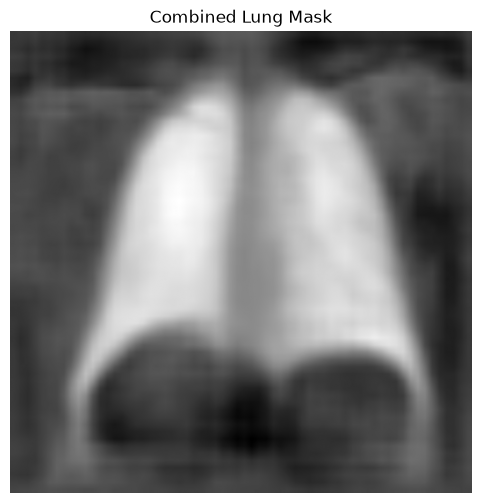

In [22]:
# ==========================================================
# STEP 12 : Display Combined Lung Mask
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(lung_mask, cmap="gray")

plt.title("Combined Lung Mask")

plt.axis("off")

plt.show()

In [23]:
# ==========================================================
# STEP 13 : Convert Probability Mask to Binary Mask
# Project : TB Detection
# Purpose :
# Convert the probability map generated by PSPNet
# into a binary lung mask.
# ==========================================================

import numpy as np

# Threshold the probability map
binary_mask = (lung_mask > 0.5).astype(np.uint8)

print("Binary Mask Created Successfully!")

print("Unique Values :", np.unique(binary_mask))

Binary Mask Created Successfully!
Unique Values : [0 1]


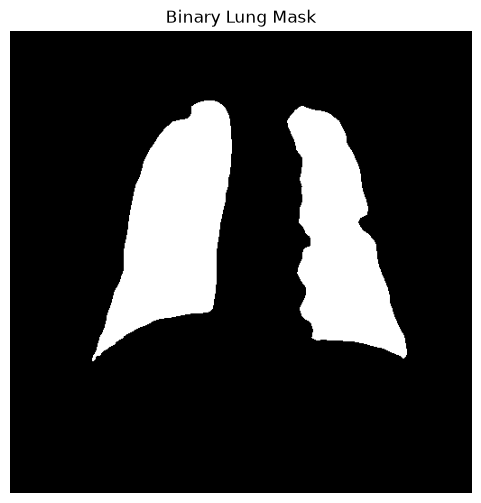

In [24]:
# ==========================================================
# STEP 14 : Display Binary Lung Mask
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(binary_mask, cmap="gray")

plt.title("Binary Lung Mask")

plt.axis("off")

plt.show()

In [25]:
# ==========================================================
# STEP 15 : Resize Binary Mask
# Purpose :
# Resize binary mask back to 224x224
# ==========================================================

binary_mask_224 = cv2.resize(
    binary_mask,
    (224,224),
    interpolation=cv2.INTER_NEAREST
)

print("Binary Mask Shape :", binary_mask_224.shape)

Binary Mask Shape : (224, 224)


In [26]:
# ==========================================================
# STEP 16 : Extract Lung Region
# Purpose :
# Keep only lung pixels
# ==========================================================

segmented_image = image * binary_mask_224

print("Segmented Image Shape :", segmented_image.shape)

Segmented Image Shape : (224, 224)


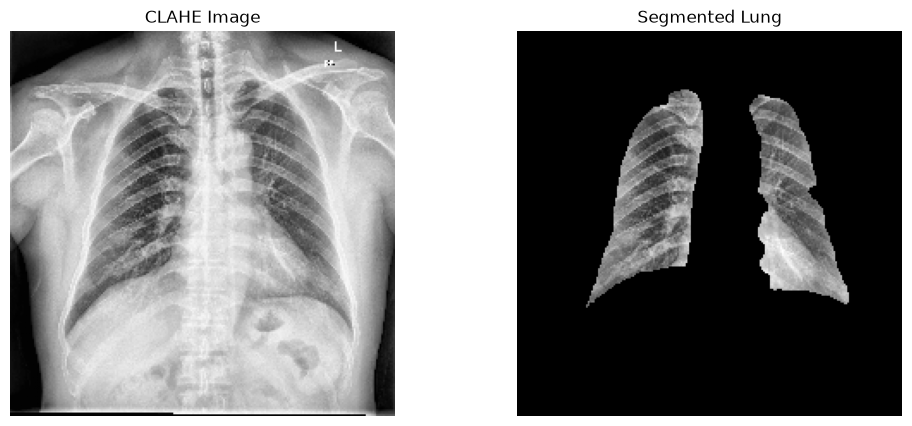

In [27]:
# ==========================================================
# STEP 17 : Compare Images
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("CLAHE Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented_image, cmap='gray')
plt.title("Segmented Lung")
plt.axis("off")

plt.show()

In [28]:
# ==========================================================
# STEP 18 : Save Segmented Image
# ==========================================================

output_path = "Segmented_Images/CHNCXR_0001_0.png"

cv2.imwrite(output_path, segmented_image)

print("Segmented Image Saved Successfully!")
print(output_path)

Segmented Image Saved Successfully!
Segmented_Images/CHNCXR_0001_0.png


In [29]:
# ==========================================================
# FINAL STEP : Segment All 800 Images
# Project : Tuberculosis Detection using CoAtNet
# Purpose :
#   1. Read all CLAHE images
#   2. Perform PSPNet lung segmentation
#   3. Create binary lung mask
#   4. Apply mask to image
#   5. Save segmented images
# ==========================================================

import os
import cv2
import torch
import numpy as np
import torchxrayvision as xrv

# -------------------------------
# Input and Output Folders
# -------------------------------

input_folder = "CLAHE_Images"
output_folder = "Segmented_Images"

os.makedirs(output_folder, exist_ok=True)

# -------------------------------
# Get all image names
# -------------------------------

image_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(".png")
])

print("=" * 50)
print("Total Images Found :", len(image_files))
print("=" * 50)

success = 0
failed = 0

# ==========================================================
# Process Every Image
# ==========================================================

for index, file_name in enumerate(image_files, start=1):

    try:

        # --------------------------------------------
        # Read Image
        # --------------------------------------------

        image_path = os.path.join(input_folder, file_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"Skipping {file_name}")
            failed += 1
            continue

        # Keep a copy of the 224×224 CLAHE image
        original_image = image.copy()

        # --------------------------------------------
        # Normalize
        # --------------------------------------------

        image_normalized = xrv.utils.normalize(
            image,
            maxval=255
        )

        # --------------------------------------------
        # Convert to Tensor
        # --------------------------------------------

        image_tensor = torch.from_numpy(image_normalized).float()

        image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.unsqueeze(0)

        # --------------------------------------------
        # Resize to 512×512
        # --------------------------------------------

        image_tensor = xrv.utils.fix_resolution(
            image_tensor,
            512,
            segmentation_model
        )

        # --------------------------------------------
        # PSPNet Prediction
        # --------------------------------------------

        with torch.no_grad():
            output = segmentation_model(image_tensor)

        # --------------------------------------------
        # Left & Right Lung
        # --------------------------------------------

        left_lung = output[0, 4].cpu().numpy()
        right_lung = output[0, 5].cpu().numpy()

        lung_mask = left_lung + right_lung

        # --------------------------------------------
        # Binary Mask
        # --------------------------------------------

        binary_mask = (lung_mask > 0.5).astype(np.uint8)

        # --------------------------------------------
        # Resize Mask Back to 224×224
        # --------------------------------------------

        binary_mask = cv2.resize(
            binary_mask,
            (224, 224),
            interpolation=cv2.INTER_NEAREST
        )

        # --------------------------------------------
        # Extract Lung Region
        # --------------------------------------------

        segmented_image = original_image * binary_mask

        # --------------------------------------------
        # Save Image
        # --------------------------------------------

        save_path = os.path.join(output_folder, file_name)

        cv2.imwrite(save_path, segmented_image)

        success += 1

        print(f"[{index}/{len(image_files)}] Saved : {file_name}")

    except Exception as e:

        failed += 1

        print(f"[{index}/{len(image_files)}] Failed : {file_name}")
        print(e)

# ==========================================================
# Final Report
# ==========================================================

print("\n" + "=" * 50)
print("Segmentation Completed Successfully")
print("=" * 50)
print("Total Images :", len(image_files))
print("Processed    :", success)
print("Failed       :", failed)
print("Saved Folder :", output_folder)
print("=" * 50)

Total Images Found : 800
[1/800] Saved : CHNCXR_0001_0.png
[2/800] Saved : CHNCXR_0002_0.png
[3/800] Saved : CHNCXR_0003_0.png
[4/800] Saved : CHNCXR_0004_0.png
[5/800] Saved : CHNCXR_0005_0.png
[6/800] Saved : CHNCXR_0006_0.png
[7/800] Saved : CHNCXR_0007_0.png
[8/800] Saved : CHNCXR_0008_0.png
[9/800] Saved : CHNCXR_0009_0.png
[10/800] Saved : CHNCXR_0010_0.png
[11/800] Saved : CHNCXR_0011_0.png
[12/800] Saved : CHNCXR_0012_0.png
[13/800] Saved : CHNCXR_0013_0.png
[14/800] Saved : CHNCXR_0014_0.png
[15/800] Saved : CHNCXR_0015_0.png
[16/800] Saved : CHNCXR_0016_0.png
[17/800] Saved : CHNCXR_0017_0.png
[18/800] Saved : CHNCXR_0018_0.png
[19/800] Saved : CHNCXR_0019_0.png
[20/800] Saved : CHNCXR_0020_0.png
[21/800] Saved : CHNCXR_0021_0.png
[22/800] Saved : CHNCXR_0022_0.png
[23/800] Saved : CHNCXR_0023_0.png
[24/800] Saved : CHNCXR_0024_0.png
[25/800] Saved : CHNCXR_0025_0.png
[26/800] Saved : CHNCXR_0026_0.png
[27/800] Saved : CHNCXR_0027_0.png
[28/800] Saved : CHNCXR_0028_0.png
[29/

In [30]:
import os

print("Segmented Images :", len(os.listdir("Segmented_Images")))

Segmented Images : 801


In [31]:
import os

files = [f for f in os.listdir("Segmented_Images") if f.endswith(".png")]

print("Total Segmented Images:", len(files))

Total Segmented Images: 800
